# Family #2 end to end from a notebook: UCSV on US core PCE inflation

Stock–Watson unobserved-components trend inflation with stochastic
volatility on **both** shocks (`pi_t = tau_t + eps_t`, `tau_t = tau_{t-1} +
eta_t`, log-variance random walks on `eps` and `eta`), estimated on US
quarterly core PCE inflation (annualized q/q %, 1960Q1–2019Q4) **through
the Python API only** — a pandas DataFrame in, a `Run` handle out. This
is the S6 WP2 worked example; `examples/us_ucsv/spec.yaml` is the same
estimation for the CLI cross-check (`mtk run` + `mtk report`), and it lands
on the **same run hash** because the spec content and data bytes match.

This notebook samples (4 chains × 1000/1000; a couple of minutes).

In [1]:
from pathlib import Path
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from macrotoolkit import api as mtk
from macrotoolkit.run import REPO_ROOT as REPO

EXAMPLE = REPO / "examples" / "us_ucsv"
df = pd.read_csv(EXAMPLE / "data" / "us_core_pce.csv", parse_dates=["date"])
df = df[df["date"] <= "2019-12-31"].reset_index(drop=True)
df.tail(3)

/root/.local/share/uv/tools/pytest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,date,core_pce_ann
237,2019-04-01,1.685094
238,2019-07-01,1.480153
239,2019-10-01,1.409132


## 1. The spec, built in Python

`sv_shocks: [eps, eta]` is the family default (SV on both shocks IS the
family). The `qc:` block is on by default: before sampling, the exact
rendered Stan program's Kalman-filter log-likelihood is cross-checked
against the Python mirror at 5 prior draws (G1's 1e-8 gate).

In [2]:
spec = mtk.spec(
    "ucsv",
    data={"file": "data/us_core_pce.csv", "date_column": "date",
          "mapping": {"pi": "core_pce_ann"}, "sample": {"end": "2019Q4"}},
    sampler={"chains": 4, "warmup": 1000, "sampling": 1000, "adapt_delta": 0.95,
             "max_treedepth": 12, "seed": 20260813},
)
print(spec.model.options, "|", spec.qc)

family='ucsv' sv_shocks=['eps', 'eta'] | mirror_check=True mirror_points=5 mirror_tolerance=1e-08 mirror_seed=20260904


## 2. Fit

We pass the CSV path relative to the example directory so the identity
matches the YAML spec exactly (a DataFrame would work too — see the lw_sv
notebook — but its canonical staging gives a different `data.file` and
therefore a different, equally valid, identity).

In [3]:
run = mtk.fit(spec, base_dir=EXAMPLE)
run

Run(f2b48ebc98a4, family='ucsv', verdict='PASS', dir='/home/user/stan-mcm/runs/f2b48ebc98a4')

In [4]:
print("hash:", run.hash, "| verdict:", run.verdict)
print("reasons:", run.diagnostics["reasons"])
mc = run.mirror_check
print(f"mirror check: {'PASS' if mc['passed'] else 'FAIL'} — max |Stan − Python| KF loglik = {mc['max_abs_diff']:.2e} over {mc['n_points']} prior draws (gate {mc['tolerance']:.0e})")

hash: f2b48ebc98a4 | verdict: PASS
reasons: ['no divergences, treedepth hits, low E-BFMI, high R-hat, or low ESS detected']
mirror check: PASS — max |Stan − Python| KF loglik = 1.14e-13 over 5 prior draws (gate 1e-08)


In [5]:
run.param_table().round(4)

,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
h0_eps_raw,-0.8139,-1.8958,0.2277,1.0016,4782.5569,3068.4861
h0_eta_raw,-0.8775,-2.1120,0.2694,1.0060,3325.1438,2937.0928
kf_loglik,-231.8585,-240.4482,-223.6417,1.0018,1422.4298,2430.0089
sigma_h_eps,0.2115,0.1080,0.3335,1.0016,1293.7788,1056.1225
sigma_h_eta,0.2904,0.1821,0.4525,1.0011,1953.9286,3088.5686


## 3. Results and figures

Trend inflation `tau`, the transitory component `pi − tau`, and the two
shock-volatility paths `exp(h/2)` (standard deviations; `h` is
log-variance).

('prior_predictive', 'trend_cycle', 'irf', 'fan', 'hd')


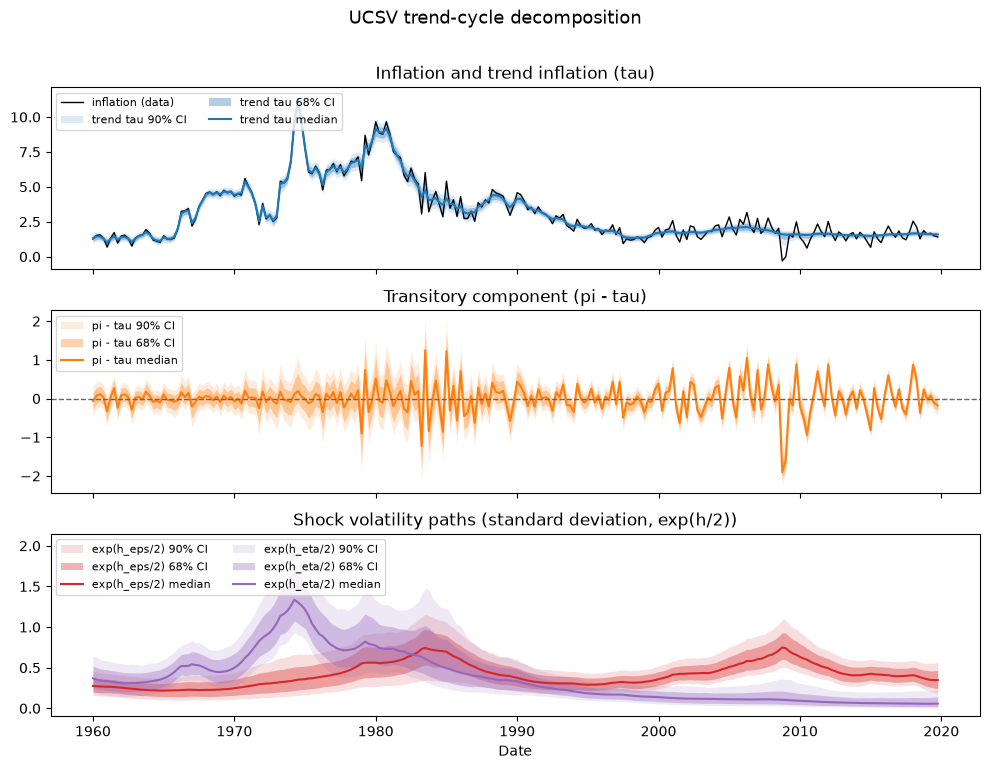

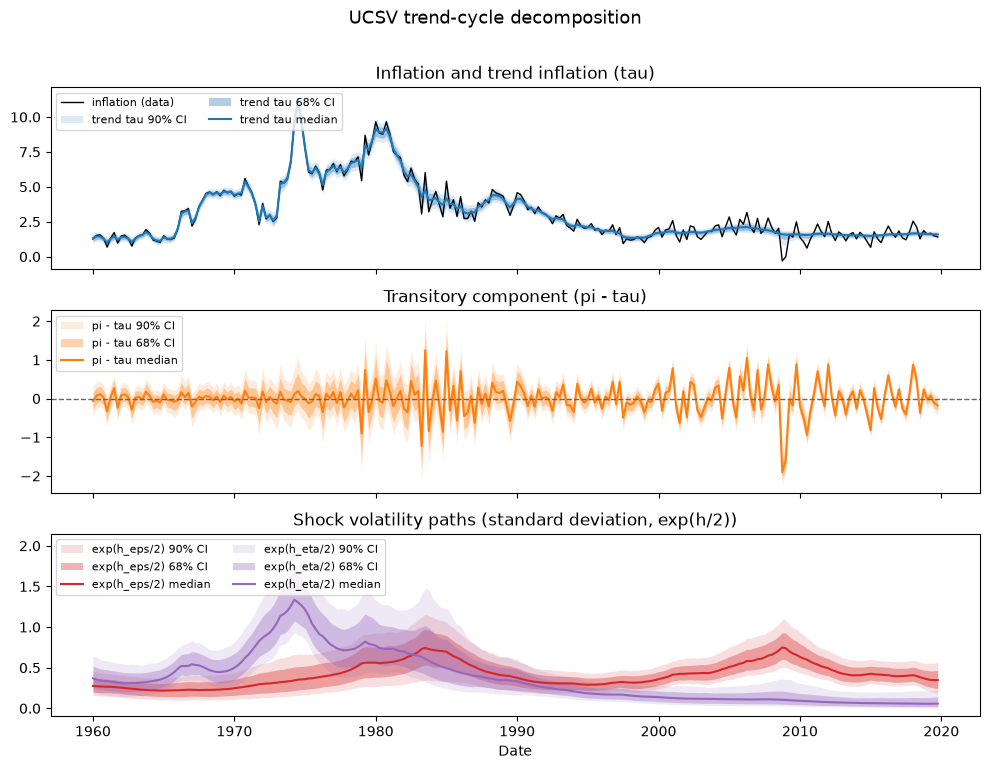

In [6]:
outs = run.outputs()
print(outs.names)
outs.figure("trend_cycle")

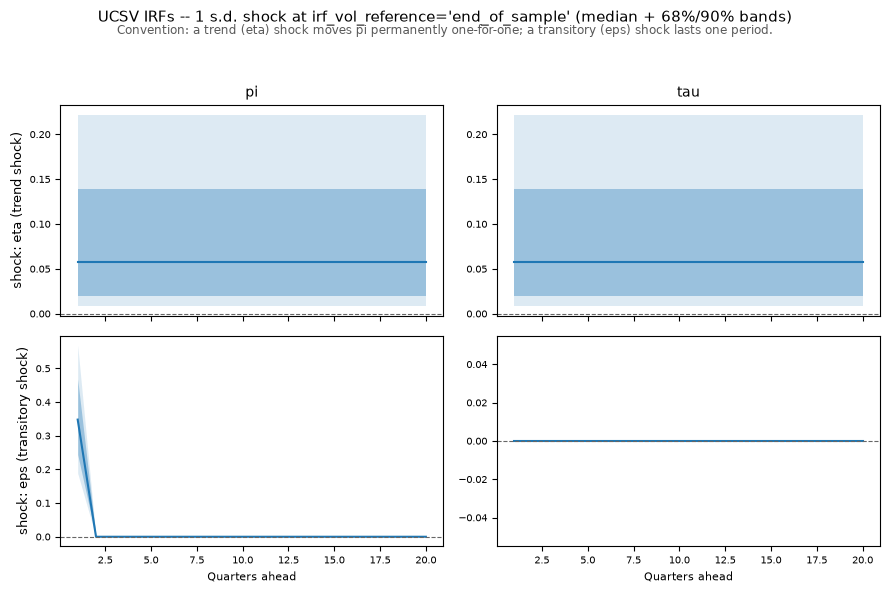

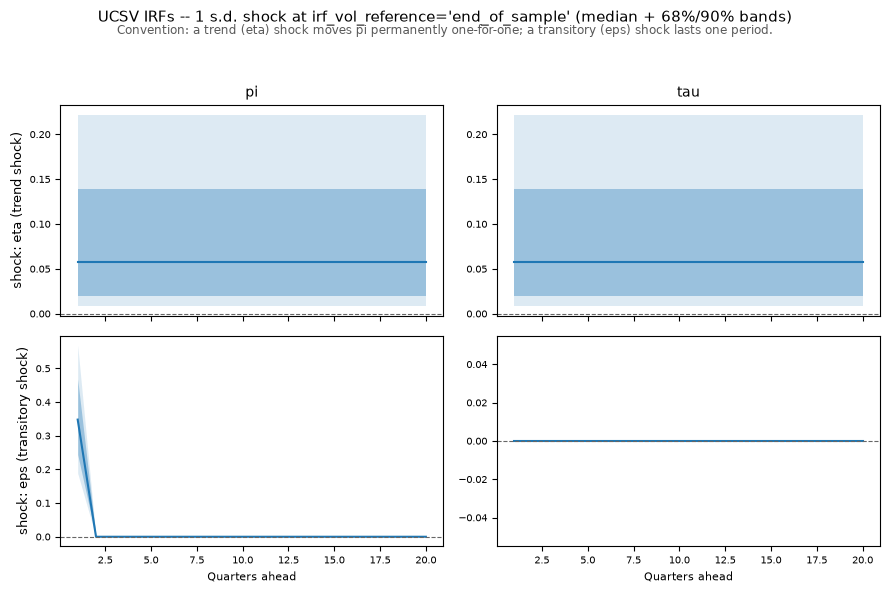

In [7]:
outs.figure("irf")

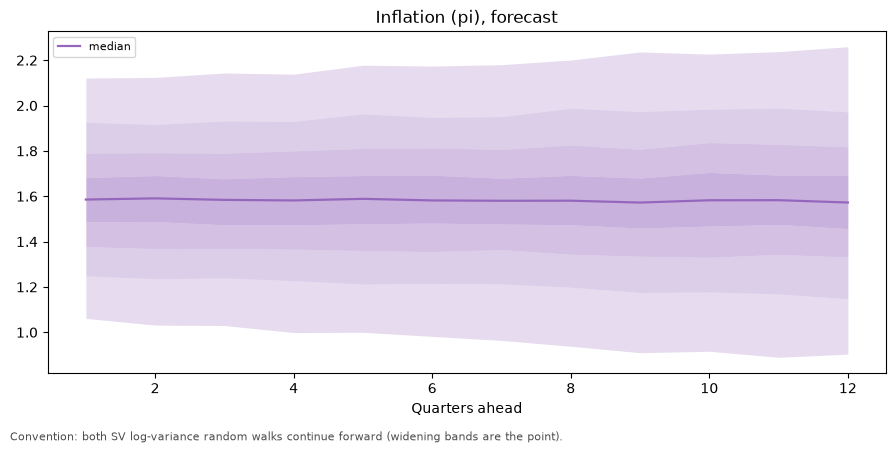

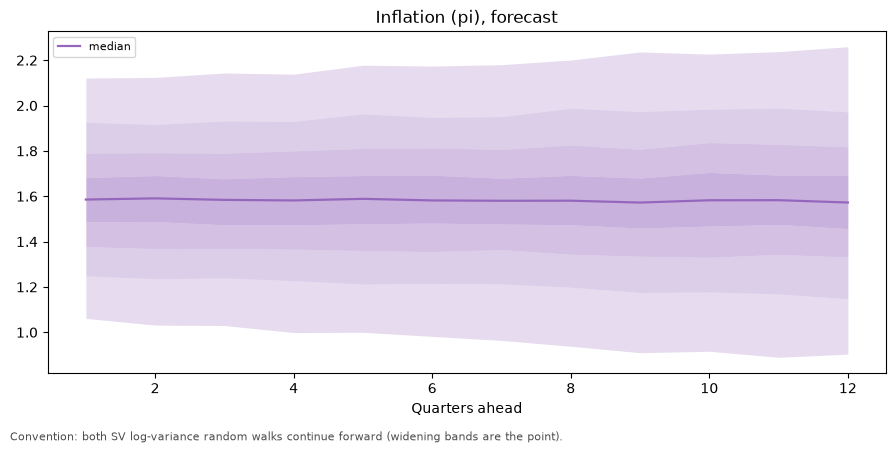

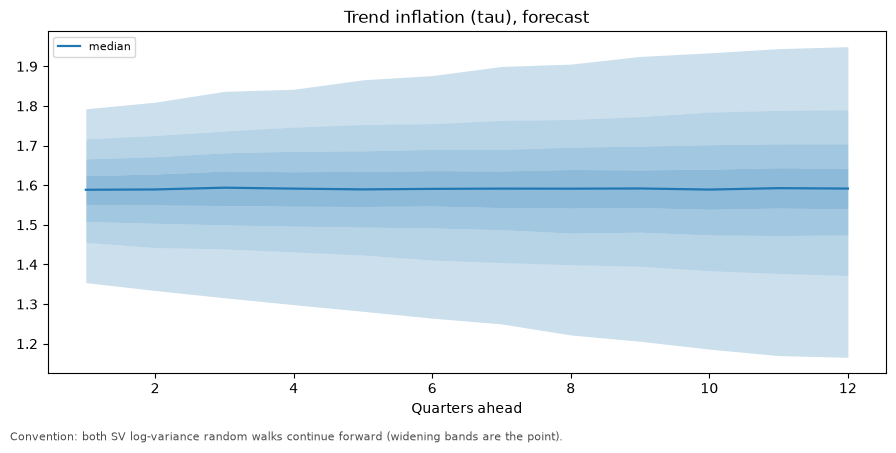

In [8]:
fans = outs.figure("fan")
fans["pi"]

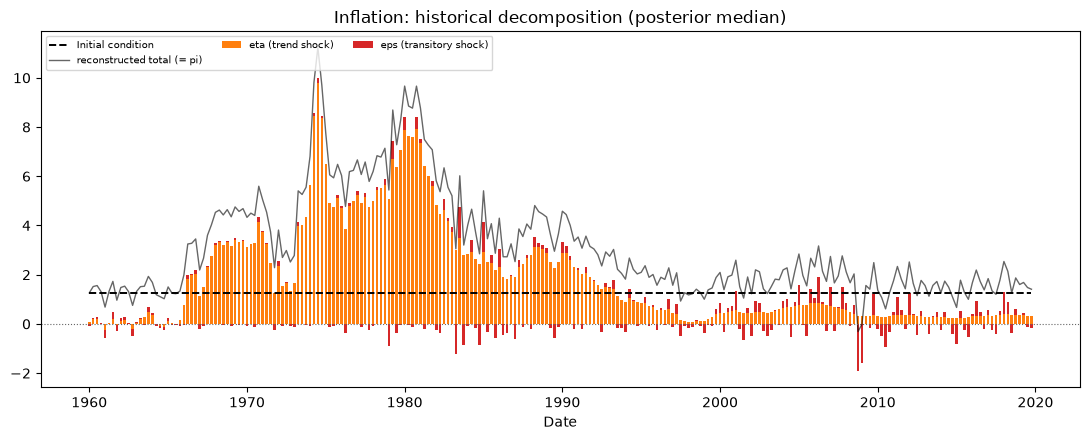

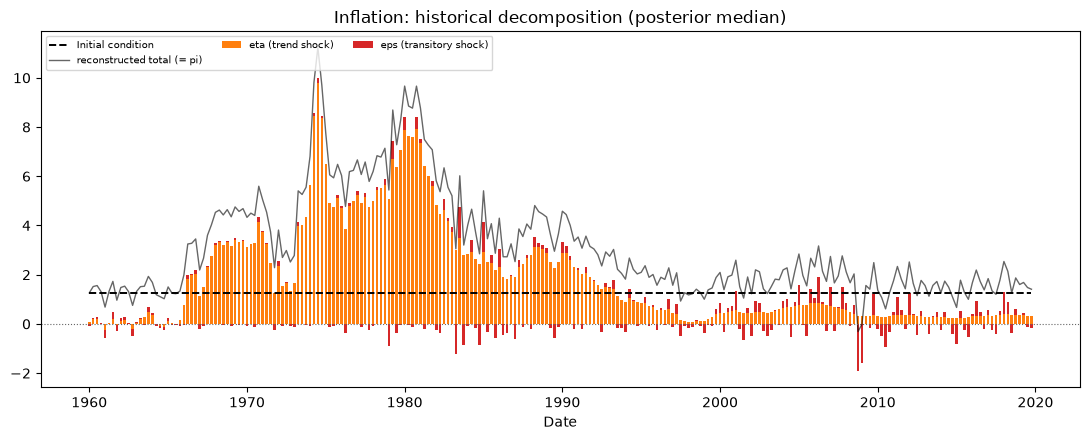

In [9]:
outs.figure("hd")["pi"]

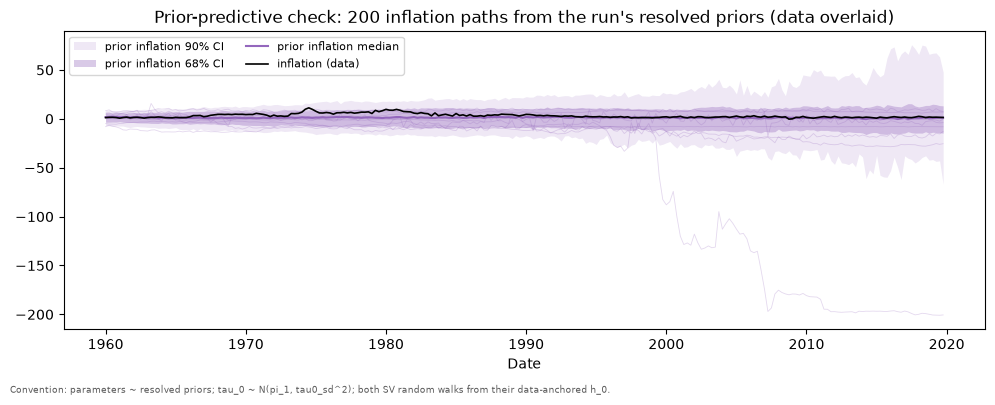

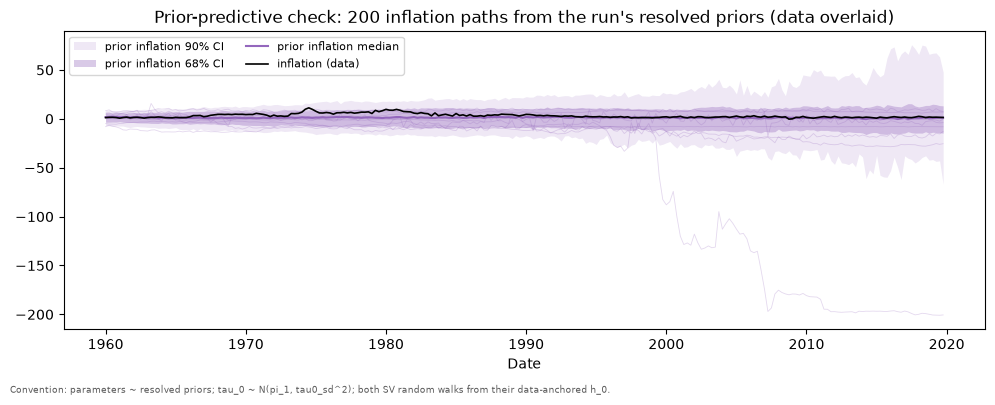

In [10]:
outs.figure("prior_predictive")

### The G6 identity, live

The historical-decomposition bars (initial condition, trend shocks,
transitory shocks) reconstruct observed inflation exactly, per period, per
draw.

In [11]:
hdd = outs.compute("hd")
total = sum(hdd.pi[k] for k in hdd.pi)
print("max |sum of bars − pi| =", np.max(np.abs(total - run.results().pi[None, :])))

max |sum of bars − pi| = 4.440892098500626e-16


## 4. Report and CLI cross-check

`run.report()` writes the self-contained `report.html` into the run
directory. The CLI equivalent of everything above is

```bash
mtk run examples/us_ucsv/spec.yaml      # same hash as `run.hash` above
mtk report <hash>
```

In [12]:
path = run.report()
print(path.name, path.stat().st_size // 1024, "KB;", path.read_text().count("<img "), "embedded figures")
plt.close("all")

report.html 569 KB; 6 embedded figures
